In [1]:
import os
import numpy as np
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Paper Search

## paper search

In [ ]:
'''
Please refer to other code.
conda activate papersearch
pycharm
'''

## merge

In [53]:
file_loc1 = r"C:\Users\yuhang.zhang\Documents\GitHub\SSSS\results\topics\district energy v3\summary.csv"
file_loc2 = r"C:\Users\yuhang.zhang\Documents\GitHub\SSSS\results\topics\district energy v4\summary.csv"
df1 = pd.read_csv(file_loc1)
df2 = pd.read_csv(file_loc2)
df1.shape # (293, 8)
df2.shape # (265, 8)

(265, 8)

In [55]:
# 找出在df2中不包含在df1中的行
df2_filtered = df2[~df2['title'].isin(df1['title'])]
# 将df2_filtered合并到df1中
merged_df = pd.concat([df1, df2_filtered], ignore_index=True)
# 显示合并后的结果
merged_df.sort_values(by=['year','num_citations','title'], ascending=[False,False,True], ignore_index=True,inplace = True)
# merged_df.to_csv(r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\Jupyter\papersearch\original_0719.csv")
merged_df #(447,8)

,title,num_citations,year,excerpt,url,url_pdf,indicator,key_words
0,Fifth-generation district heating and cooling ...,13,2023,… Bidirectional energy flows have important im...,https://www.sciencedirect.com/science/article/...,NaN,0,"bidirectional, district energy"
1,District heating and cooling networks with dec...,6,2023,… heat decarbonisation arsenal is unclear as e...,https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
2,Design optimization of a district heating and ...,5,2023,… energy storages are implemented in newer gen...,https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
3,The efficiency of innovative technologies for ...,3,2023,… and 5th generations … heat recovery from the...,https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
4,nPro: A web-based planning tool for designing ...,3,2023,… These decentralized and bidirectional local ...,https://www.sciencedirect.com/science/article/...,NaN,0,"bidirectional, district energy"
...,...,...,...,...,...,...,...,...
442,Static study of traditional and ring networks ...,68,2013,… District heating is a widely used form of he...,https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
443,Bioenergy production and use in Italy: Recent ...,44,2013,"… origin, while in the heating and cooling sec...",https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
444,Economic viability of incorporating multi-effe...,18,2013,… district cooling. The results indicate that ...,https://www.sciencedirect.com/science/article/...,NaN,0,"low temperature, district cooling"
445,Towards an architecture for integrated Gas Dis...,14,2013,"… Thus, this paper focuses on exploring more e...",https://ieeexplore.ieee.org/abstract/document/...,NaN,0,"5th generation, district cooling"


## filter

In [ ]:
# simple filter based on the title

In [3]:
filtered_df = pd.read_csv(r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\Jupyter\papersearch\filtered_0719.csv")
filtered_df.shape # (359, 9)

(359, 9)

In [4]:
file_path = r'C:\Users\yuhang.zhang\Documents\GitHub\SSSS\results\topics\240111QE'
file_loc1 = os.path.join(file_path,"summary.csv")
file_loc2 = os.path.join(file_path,"export.csv")
df1 = pd.read_csv(file_loc1)
df2 = pd.read_csv(file_loc2)
df1.shape # (293, 8)
df2.shape # (265, 8)

(81, 87)

In [11]:
file_path = r'C:\Users\yuhang.zhang\Documents\GitHub\SSSS\results\topics\240111QE'
export_file = os.path.join(file_path, "export.csv")
updated_summary_file = os.path.join(file_path, "updated_summary.csv")
export_df = pd.read_csv(export_file)
updated_summary_df = pd.read_csv(updated_summary_file)


## search DOI

In [5]:
import csv
import requests
import time
import os

# file_name = 'filtered_0719.csv'
# file_loc = os.path.join(r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\Jupyter\papersearch",file_name)
# target_loc = os.path.join(r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\Jupyter\papersearch",'updated_'+ file_name)

file_path = r'C:\Users\yuhang.zhang\Documents\GitHub\SSSS\results\topics\240111QE'
file_name = 'summary.csv'
file_loc = os.path.join(file_path,file_name)
target_loc = os.path.join(file_path,'updated_'+ file_name)

# 打开CSV文件并读取内容
with open(file_loc, 'r', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    
    # 创建一个新的CSV文件来存储结果
    with open(target_loc, 'w', newline='', encoding='utf-8') as outputfile:
        fieldnames = ['title', 'url', 'doi', 'authors', 'type', 'publisher', 'issued']
        writer = csv.DictWriter(outputfile, fieldnames=fieldnames)

        writer.writeheader()
        
        for row in reader:
            # 从每一行获取标题和URL
            title = row['title']
            url = row['url']
            
            # 使用Crossref API进行搜索
            response = requests.get('https://api.crossref.org/works?query.title=' + title)

            # 初始化所有信息为空
            doi = ''
            authors = ''
            type_ = ''
            publisher = ''
            issued = ''

            # 检查是否有结果
            if response.status_code == 200:
                try:
                    # 获取搜索结果中的第一项
                    first_result = response.json()['message']['items'][0]

                    # 从第一项中获取DOI
                    doi = first_result['DOI']

                    # 从第一项中获取类型
                    type_ = first_result['type']

                    # 从第一项中获取出版商
                    publisher = first_result['publisher']

                    # 从第一项中获取发布日期，这里的改变就是先将日期列表中的元素转换为字符串
                    issued = '-'.join(map(str, first_result['issued']['date-parts'][0]))

                    # 从第一项中获取作者
                    authors_list = first_result.get('author', [])
                    if authors_list:
                        authors = '; '.join([
                            ' '.join([author.get('given', ''), author.get('family', '')]) 
                            for author in authors_list
                        ])
                    else:
                        authors = ''
                    
#                     print("Title:", title)
#                     print("DOI:", doi)
#                     print("Authors:", authors)
#                     print("Type:", type_)
#                     print("Publisher:", publisher)
#                     print("Issued:", issued)
#                     print("---------")
                except IndexError:
                    print(f"No results found for {title}")
                    print("---------")

            # 将标题、URL和DOI写入新的CSV文件
            writer.writerow({
                'title': title, 
                'url': url, 
                'doi': doi,
                'authors': authors,
                'type': type_,
                'publisher': publisher,
                'issued': issued
            })

            # 为了避免API的使用频率过高，我们在每次请求后等待一秒钟
            time.sleep(1)

In [24]:
# optional - 筛选删除 updated_summary 中 在export中重复的部分

# Load the datasets
file_path = r'C:\Users\yuhang.zhang\Documents\GitHub\SSSS\results\topics\240111QE'
export_file = os.path.join(file_path, "export.csv")
updated_summary_file = os.path.join(file_path, "updated_summary.csv")
export_df = pd.read_csv(export_file)
updated_summary_df = pd.read_csv(updated_summary_file)

# Convert 'DOI' columns to lowercase for case-insensitive comparison
export_df['DOI'] = export_df['DOI'].str.lower()
updated_summary_df['doi'] = updated_summary_df['doi'].str.lower()

# Filter updated_summary_df to exclude rows present in export_df based on 'DOI'
filtered_df = updated_summary_df[~updated_summary_df['doi'].isin(export_df['DOI'])]

print(updated_summary_df.shape)
print(filtered_df.shape)

# filtered_df.to_csv(os.path.join(file_path, "filtered.csv"), index=False)

filtered_df

(160, 7)
(144, 7)


,title,url,doi,authors,type,publisher,issued
0,"Effects of ambient pressure, gas temperature a...",https://www.sciencedirect.com/science/article/...,10.1016/j.combustflame.2013.09.009,Tomoaki Kitano; Jun Nishio; Ryoichi Kurose; Sa...,journal-article,Elsevier BV,2014-2
1,The influence of initial sizes and velocities ...,https://www.sciencedirect.com/science/article/...,10.1016/j.ijheatmasstransfer.2014.09.006,Roman S. Volkov; Geniy V. Kuznetsov; Pavel A. ...,journal-article,Elsevier BV,2014-12
2,An experimental investigation on dynamics and ...,https://www.degruyter.com/document/doi/10.3139...,10.3139/124.110742,J. Park; H. Kim,journal-article,Walter de Gruyter GmbH,2016-6-11
3,Biodegradation of dispersed Macondo oil in sea...,https://www.sciencedirect.com/science/article/...,10.1016/j.marpolbul.2015.02.006,Odd G. Brakstad; Trond Nordtug; Mimmi Throne-H...,journal-article,Elsevier BV,2015-4
4,Temperature effects on droplet oscillation dec...,https://www.dl.begellhouse.com/journals/6a7c7e...,10.1615/atomizspr.2021039068,Wanjun Dang; M. Gurunadhan; I. Schoegl; S. Menon,journal-article,Begell House,2021
...,...,...,...,...,...,...,...
154,Investigation on heat transfer characteristics...,https://www.sciencedirect.com/science/article/...,10.1016/j.ijheatmasstransfer.2018.05.039,Ting Xue; Shangzhen Zhang,journal-article,Elsevier BV,2018-11
155,High precision in-cylinder gas thermometry usi...,https://www.sciencedirect.com/science/article/...,10.1016/j.combustflame.2013.07.018,Ben Williams; Megan Edwards; Richard Stone; Jo...,journal-article,Elsevier BV,2014-1
156,… Concentration Fields and Trajectory Investig...,https://arc.aiaa.org/doi/pdf/10.2514/6.2016-0906,10.2514/6.2016-0906,Marissa K. Geikie; Johnathan Sosa; Craig P. Fe...,proceedings-article,American Institute of Aeronautics and Astronau...,2016-1-2
157,Heat transfer enhancement in wavy falling film...,https://www.sciencedirect.com/science/article/...,10.1016/j.ijheatmasstransfer.2022.123690,R. Collignon; O. Caballina; F. Lemoine; C.N. M...,journal-article,Elsevier BV,2023-3


## 转换成ris文件

In [ ]:
'''
两种方式批量导入zotero:
method 1：批量下载pdf，导入zotero
# 目前尚未实现，由于SciHub包中的链接已不受支持
pros: metadata自动更新 
cons: 遗漏的条目还是要通过rsi导入

method 2: csv转成rsi文件
pros:基本不会遗漏条目
cons:meta data不能自动更新；type不能正确识别
'''

In [ ]:
'''
Journal Article（期刊文章）：TY - JOUR
Book（书籍）：TY - BOOK
Book Section（书籍章节）：TY - CHAP
Thesis（论文）：TY - THES
Conference Paper（会议论文）：TY - CONF
Report（报告）：TY - RPRT
Patent（专利）：TY - PAT
Web Page（网页）：TY - WEB
Electronic Article（电子文章）：TY - ELEC
Artwork（艺术作品）：TY - ART
Computer Program（计算机程序）：TY - COMP
Interview（采访）：TY - INPR
Email（电子邮件）：TY - ELEC
Audiovisual Material（音频视频资料）：TY - AV
Dictionary Entry（词典条目）：TY - DICT
Legislation（法规文件）：TY - LEGAL
Manuscript（手稿）：TY - MS
Map（地图）：TY - MAP
Personal Communication（个人交流）：TY - PCOMM
Unpublished Work（未发表作品）：TY - UNPB
'''

In [25]:
import csv
import os

file_path = r'C:\Users\yuhang.zhang\Documents\GitHub\SSSS\results\topics\240111QE'
file_name = "filtered"
csvfile =  os.path.join(file_path,file_name + '.csv')
risfile = os.path.join(file_path,file_name + '.ris')

# 定义类型映射字典
type_mapping = {
    "journal-article": "JOUR",
    "book-chapter": "CHAP",
    "book": "BOOK",
    "conference-paper": "CONF",
    "proceedings-article":"CONF",
    "report": "RPRT",
    "patent": "PAT",
    # 添加其他类型的映射关系
}

with open(csvfile, 'r', encoding='utf-8') as inputfile, open(risfile, 'w', encoding='utf-8') as outputfile:
    reader = csv.DictReader(inputfile)

    for row in reader:
        crossref_type = row['type']
        # 转换为RIS格式中的类型值
        if crossref_type in type_mapping:
            ris_type = type_mapping[crossref_type]
        else:
            ris_type = "GEN"  # 如果类型未映射，则使用通用类型
            
        outputfile.write("TY  - {0}\n".format(ris_type))
        outputfile.write("TI  - {0}\n".format(row['title']))
        for author in row['authors'].split(';'):
            outputfile.write("AU  - {0}\n".format(author.strip()))
        outputfile.write("DO  - {0}\n".format(row['doi']))
        outputfile.write('PB  - ' + row['publisher'] + '\n')  # PB - 出版商
        outputfile.write("PY  - {0}\n".format(row['issued'].split('-')[0]))
#         outputfileY  - ' + row['issued'][:4] + '\n')  # PY - 年份
        outputfile.write('UR  - ' + row['url'] + '\n')  # UR - URL
        outputfile.write("ER  - \n\n")

## download papers

In [2]:
from scihub import SciHub
import csv
import os

# 实例化SciHub对象
sh = SciHub()

# 定义PDF存放路径
pdf_folder = r"C:\Users\yuhang.zhang\Documents\pdfs"
file_name = "Exported Items.csv"

# 如果不存在该文件夹, 则创建
if not os.path.exists(pdf_folder):
    os.mkdir(pdf_folder)

target_loc = os.path.join(pdf_folder,file_name)
with open(target_loc, 'r', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        doi = row['DOI']
        if doi:  # 如果DOI存在
            try:
                # 从Sci-Hub获取PDF
                result = sh.fetch(doi)
                pdf_path = os.path.join(pdf_folder, f"{doi.replace('/', '_')}.pdf")
                with open(pdf_path, 'wb') as f_out:
                    f_out.write(result['pdf'])
                print(f'Successfully downloaded pdf for doi: {doi}')
            except Exception as e:
                print(f'Failed to download pdf for doi: {doi}, error: {str(e)}')

INFO:scihub:1 Downloading with https://sci-hub.tw/
DEBUG:scihub:id_type = doi
DEBUG:scihub:Pinging https://sci-hub.tw/
C:\Users\yuhang.zhang\.conda\envs\yuhang\Lib\site-packages\urllib3\connectionpool.py:1095: InsecureRequestWarning: Unverified HTTPS request is being made to host 'sci-hub.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
INFO:scihub:Server https://sci-hub.tw/ is up
INFO:scihub:scihub url https://sci-hub.tw/10.1092/q9u9-11hc-c6gh-59t0
C:\Users\yuhang.zhang\.conda\envs\yuhang\Lib\site-packages\urllib3\connectionpool.py:1095: InsecureRequestWarning: Unverified HTTPS request is being made to host 'sci-hub.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
DEBUG:scihub:Scraping scihub site
INFO:scihub:Changing to sci-hub.is
INFO:scihub:2 Downloading with https://sci-hub.

Failed to download pdf for doi: 10.1092/q9u9-11hc-c6gh-59t0, error: Direct url could not be retrieved


INFO:scihub:Changing to 80.82.77.83
INFO:scihub:5 Downloading with https://80.82.77.83/
DEBUG:scihub:id_type = url-non-direct
DEBUG:scihub:Pinging https://80.82.77.83/
INFO:scihub:Changing to sci-hub.mn
INFO:scihub:6 Downloading with https://sci-hub.mn/
DEBUG:scihub:id_type = url-non-direct
DEBUG:scihub:Pinging https://sci-hub.mn/


KeyboardInterrupt: 

In [13]:
# -*- coding: utf-8 -*-
# https://github.com/Tishacy/SciDownl/blob/v1.0/example/simple.py
from scidownl import scihub_download
    
# 定义PDF存放路径
pdf_folder = r"C:\Users\yuhang.zhang\Documents\pdfs"
file_name = "Exported Items.csv"

# 如果不存在该文件夹, 则创建
if not os.path.exists(pdf_folder):
    os.mkdir(pdf_folder)

target_loc = os.path.join(pdf_folder,file_name)
with open(target_loc, 'r', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        doi =  "https://doi.org/" + row['DOI']
        if doi:  # 如果DOI存在
            pdf_path = os.path.join(pdf_folder, f"{row['DOI'].replace('/', '_')}.pdf")
            scihub_download(doi, paper_type="doi", out=pdf_path)


[INFO] | 2023/07/20 03:07:25 | Choose scihub url [0]: https://sci-hub.se
[INFO] | 2023/07/20 03:07:25 | <- Request: scihub_url=https://sci-hub.se, source=DoiSource[type=doi, id=doi.org/10.1016/j.energy.2022.126575], proxies={}
[INFO] | 2023/07/20 03:07:26 | -> Response: status_code=200, content_length=5837
[WARNING] | 2023/07/20 03:07:26 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:07:26 | Choose scihub url [1]: http://sci-hub.se
[INFO] | 2023/07/20 03:07:26 | <- Request: scihub_url=http://sci-hub.se, source=DoiSource[type=doi, id=doi.org/10.1016/j.energy.2022.126575], proxies={}
[INFO] | 2023/07/20 03:07:27 | -> Response: status_code=200, content_length=5837
[WARNING] | 2023/07/20 03:07:27 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:07:27 | Choose scihub url [2]: https://sci-hub.ru
[INFO] 

[INFO] | 2023/07/20 03:07:48 | Choose scihub url [2]: https://sci-hub.ru
[INFO] | 2023/07/20 03:07:48 | <- Request: scihub_url=https://sci-hub.ru, source=DoiSource[type=doi, id=doi.org/10.1016/j.jobe.2023.106533], proxies={}
[INFO] | 2023/07/20 03:07:49 | -> Response: status_code=200, content_length=5835
[WARNING] | 2023/07/20 03:07:49 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:07:49 | Choose scihub url [3]: http://sci-hub.st
[INFO] | 2023/07/20 03:07:49 | <- Request: scihub_url=http://sci-hub.st, source=DoiSource[type=doi, id=doi.org/10.1016/j.jobe.2023.106533], proxies={}
[INFO] | 2023/07/20 03:07:50 | -> Response: status_code=200, content_length=5835
[WARNING] | 2023/07/20 03:07:50 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:07:50 | Choose scihub url [4]: http://sci-hub.ru
[INFO] | 202

[INFO] | 2023/07/20 03:08:05 | Choose scihub url [4]: http://sci-hub.ru
[INFO] | 2023/07/20 03:08:05 | <- Request: scihub_url=http://sci-hub.ru, source=DoiSource[type=doi, id=doi.org/10.1016/j.segy.2023.100095], proxies={}
[INFO] | 2023/07/20 03:08:05 | -> Response: status_code=200, content_length=5835
[WARNING] | 2023/07/20 03:08:05 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:08:05 | Choose scihub url [5]: https://sci-hub.st
[INFO] | 2023/07/20 03:08:05 | <- Request: scihub_url=https://sci-hub.st, source=DoiSource[type=doi, id=doi.org/10.1016/j.segy.2023.100095], proxies={}
[INFO] | 2023/07/20 03:08:06 | -> Response: status_code=200, content_length=5835
[WARNING] | 2023/07/20 03:08:06 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[ERROR] | 2023/07/20 03:08:06 | Failed to download the paper: https://doi.org/10.101

[ERROR] | 2023/07/20 03:08:27 | Failed to download the paper: https://doi.org/10.1016/j.energy.2023.126746. Please try again.
[INFO] | 2023/07/20 03:08:27 | Choose scihub url [0]: https://sci-hub.se
[INFO] | 2023/07/20 03:08:27 | <- Request: scihub_url=https://sci-hub.se, source=DoiSource[type=doi, id=doi.org/10.1016/j.jobe.2023.107138], proxies={}
[INFO] | 2023/07/20 03:08:29 | -> Response: status_code=200, content_length=5835
[WARNING] | 2023/07/20 03:08:29 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:08:29 | Choose scihub url [1]: http://sci-hub.se
[INFO] | 2023/07/20 03:08:29 | <- Request: scihub_url=http://sci-hub.se, source=DoiSource[type=doi, id=doi.org/10.1016/j.jobe.2023.107138], proxies={}
[INFO] | 2023/07/20 03:08:30 | -> Response: status_code=200, content_length=5835
[WARNING] | 2023/07/20 03:08:30 | Error occurs, task status: extracting_failed, error: No pdf tag was found in 

[INFO] | 2023/07/20 03:08:43 | -> Response: status_code=200, content_length=5837
[WARNING] | 2023/07/20 03:08:43 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:08:43 | Choose scihub url [2]: https://sci-hub.ru
[INFO] | 2023/07/20 03:08:43 | <- Request: scihub_url=https://sci-hub.ru, source=DoiSource[type=doi, id=doi.org/10.1016/j.energy.2023.128347], proxies={}
[INFO] | 2023/07/20 03:08:44 | -> Response: status_code=200, content_length=5837
[WARNING] | 2023/07/20 03:08:44 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:08:44 | Choose scihub url [3]: http://sci-hub.st
[INFO] | 2023/07/20 03:08:44 | <- Request: scihub_url=http://sci-hub.st, source=DoiSource[type=doi, id=doi.org/10.1016/j.energy.2023.128347], proxies={}
[INFO] | 2023/07/20 03:08:45 | -> Response: status_code=200, content_length=5837

...

[INFO] | 2023/07/20 03:11:35 | ↓ Successfully download the url to: C:\Users\yuhang.zhang\Documents\pdfs\10.1016_j.egyr.2021.08.146.pdf
[INFO] | 2023/07/20 03:11:35 | Choose scihub url [0]: https://sci-hub.se
[INFO] | 2023/07/20 03:11:35 | <- Request: scihub_url=https://sci-hub.se, source=DoiSource[type=doi, id=doi.org/10.1299/jsmeicope.2021.15.2021-0225], proxies={}
[INFO] | 2023/07/20 03:11:37 | -> Response: status_code=200, content_length=5844
[WARNING] | 2023/07/20 03:11:37 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:11:37 | Choose scihub url [1]: http://sci-hub.se
[INFO] | 2023/07/20 03:11:37 | <- Request: scihub_url=http://sci-hub.se, source=DoiSource[type=doi, id=doi.org/10.1299/jsmeicope.2021.15.2021-0225], proxies={}
[INFO] | 2023/07/20 03:11:38 | -> Response: status_code=200, content_length=5844
[WARNING] | 2023/07/20 03:11:38 | Error occurs, task status: extracting_failed, erro

100% [==================================================] 146/146


[INFO] | 2023/07/20 03:11:52 | ↓ Successfully download the url to: C:\Users\yuhang.zhang\Documents\pdfs\10.1016_j.segy.2022.100064.pdf
[INFO] | 2023/07/20 03:11:52 | Choose scihub url [0]: https://sci-hub.se
[INFO] | 2023/07/20 03:11:52 | <- Request: scihub_url=https://sci-hub.se, source=DoiSource[type=doi, id=doi.org/10.1007/978-3-319-41022-7_20], proxies={}
[INFO] | 2023/07/20 03:11:54 | -> Response: status_code=200, content_length=6294
[WARNING] | 2023/07/20 03:11:54 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:11:54 | Choose scihub url [1]: http://sci-hub.se
[INFO] | 2023/07/20 03:11:54 | <- Request: scihub_url=http://sci-hub.se, source=DoiSource[type=doi, id=doi.org/10.1007/978-3-319-41022-7_20], proxies={}
[INFO] | 2023/07/20 03:11:56 | -> Response: status_code=200, content_length=6294
[WARNING] | 2023/07/20 03:11:56 | Error occurs, task status: extracting_failed, error: No pdf tag 

[INFO] | 2023/07/20 03:12:11 | Choose scihub url [2]: https://sci-hub.ru
[INFO] | 2023/07/20 03:12:11 | <- Request: scihub_url=https://sci-hub.ru, source=DoiSource[type=doi, id=doi.org/10.1016/j.scs.2022.104382], proxies={}
[INFO] | 2023/07/20 03:12:12 | -> Response: status_code=200, content_length=5834
[WARNING] | 2023/07/20 03:12:12 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:12:12 | Choose scihub url [3]: http://sci-hub.st
[INFO] | 2023/07/20 03:12:12 | <- Request: scihub_url=http://sci-hub.st, source=DoiSource[type=doi, id=doi.org/10.1016/j.scs.2022.104382], proxies={}
[INFO] | 2023/07/20 03:12:14 | -> Response: status_code=200, content_length=5834
[WARNING] | 2023/07/20 03:12:14 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:12:14 | Choose scihub url [4]: http://sci-hub.ru
[INFO] | 2023/

[INFO] | 2023/07/20 03:12:26 | Choose scihub url [4]: http://sci-hub.ru
[INFO] | 2023/07/20 03:12:26 | <- Request: scihub_url=http://sci-hub.ru, source=DoiSource[type=doi, id=doi.org/10.1016/j.segy.2023.100095], proxies={}
[INFO] | 2023/07/20 03:12:27 | -> Response: status_code=200, content_length=5835
[WARNING] | 2023/07/20 03:12:27 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[INFO] | 2023/07/20 03:12:27 | Choose scihub url [5]: https://sci-hub.st
[INFO] | 2023/07/20 03:12:27 | <- Request: scihub_url=https://sci-hub.st, source=DoiSource[type=doi, id=doi.org/10.1016/j.segy.2023.100095], proxies={}
[INFO] | 2023/07/20 03:12:28 | -> Response: status_code=200, content_length=5835
[WARNING] | 2023/07/20 03:12:28 | Error occurs, task status: extracting_failed, error: No pdf tag was found in the given content with the selector: #pdf
[ERROR] | 2023/07/20 03:12:28 | Failed to download the paper: https://doi.org/10.101

# Word Cloud

## Publication numbers

In [2]:
#     D:\Github\word-cloud\results\topics\machine learning control\summary.csv
file_loc = r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\30 - Papers\2401_ULTDHCReview\Code"
file_name = "summary.csv"
df = pd.read_csv(os.path.join(file_loc,file_name)
# df = pd.read_csv(r"C:\Users\yuhang.zhang\Documents\GitHub\SSSS\results\topics\district energy v2\summary.csv"
                 , encoding="latin-1"
#                  , names=["titles"]
                 ,index_col=0) 
df 

,title,num_citations,year,excerpt,url,url_pdf,indicator,key_words
0,Heat pump efficiency in fifth generation ultra...,37,2021,Ã¢ÂÂ¦ at source supply temperatures between 0...,https://www.sciencedirect.com/science/article/...,NaN,0,"ultra-low temperature, district heat pump"
1,Ultra-low temperature district heating system ...,50,2018,"Ã¢ÂÂ¦ total heat supply. In this study, the a...",https://www.sciencedirect.com/science/article/...,NaN,0,"ultra-low temperature, district heat pump"
2,Evaluating the cost of heat for end users in u...,82,2018,Ã¢ÂÂ¦ of district heating systems with distri...,https://www.sciencedirect.com/science/article/...,NaN,0,"ultra-low temperature, district heat pump"
3,Performance of ultra low temperature district ...,76,2017,Ã¢ÂÂ¦ of booster heat pumps in ultra low temp...,https://www.sciencedirect.com/science/article/...,NaN,0,"ultra-low temperature, district heat pump"
4,Steady state behavior of a booster heat pump f...,14,2021,Ã¢ÂÂ¦ heat pumps (BHP) in district heating sy...,https://www.sciencedirect.com/science/article/...,NaN,0,"ultra-low temperature, district heat pump"
...,...,...,...,...,...,...,...,...
224,Cryoprotectants: A review of the actions and a...,384,2017,Ã¢ÂÂ¦ We have used the term Ã¢ÂÂultra-lowÃ¢...,https://www.sciencedirect.com/science/article/...,NaN,0,"ultra-low temperature, district cooling"
225,High energy density hybrid Mg 2+/Li+ battery w...,60,2016,Ã¢ÂÂ¦ to afford appropriate power capability ...,https://pubs.rsc.org/en/content/articlehtml/20...,NaN,0,"ultra-low temperature, district cooling"
226,Liquid-metal electrode to enable ultra-low tem...,151,2014,Ã¢ÂÂ¦ Once the NaÃ¢ÂÂCs alloy was wetting t...,https://www.nature.com/articles/ncomms5578,NaN,0,"ultra-low temperature, district cooling"
227,Non-plasmonic nanoantennas for surface enhance...,486,2015,Ã¢ÂÂ¦ Via the realization of a novel nanophot...,https://www.nature.com/articles/ncomms8915,NaN,0,"ultra-low temperature, district cooling"


(359, 9)


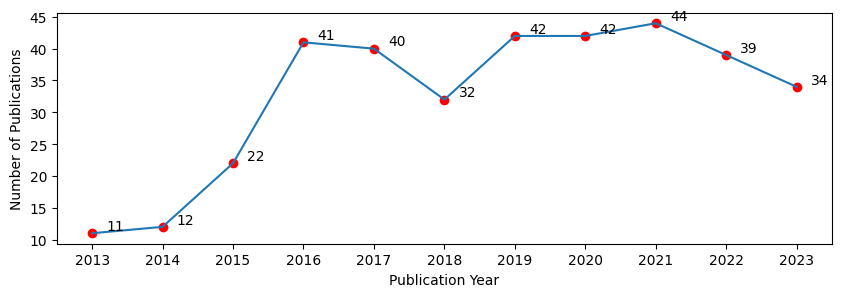

In [102]:
file_loc = r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\30 - Papers\2401_ULTDHCReview\Literature"
pic_loc = r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\30 - Papers\2401_ULTDHCReview\Pictures"
merged_df = pd.read_csv(os.path.join(file_loc,"original_0719.csv"))
filtered_df = pd.read_csv(os.path.join(file_loc,"filtered_0719.csv"))
df = filtered_df.copy()
print(df.shape) # (359, 9)

fig, ax = plt.subplots(figsize=(10,3))
df_yr = df['year'].value_counts().sort_index()

x = df_yr.index
y = df_yr

# Plot the line
plt.plot(x, y, '-')
plt.scatter(x, y, color='red')

# Add text labels to the dots
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.annotate(f'{yi}', xy=(xi, yi), xytext=(xi + 0.2, yi + 0.5))
    
# Set axis labels and title
ax.set_xlabel('Publication Year')
ax.set_ylabel('Number of Publications')
# ax.set_title('My Line Chart')

plt.xticks(range(min(x), max(x) + 1, 1))
# plt.savefig(os.path.join(pic_loc,"trend.svg"))
plt.show()

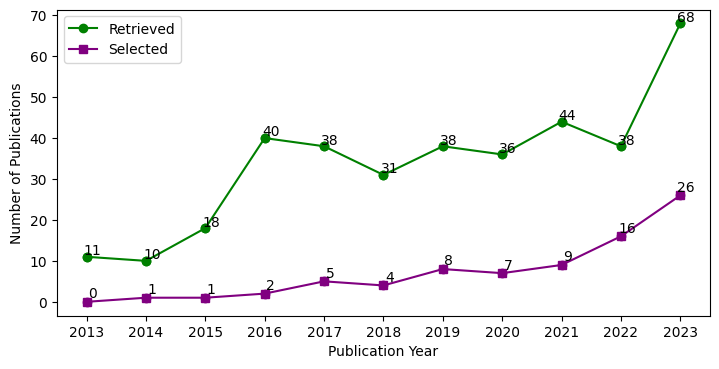

In [8]:
# 240719
import pandas as pd
import matplotlib.pyplot as plt
import os

file_loc = r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\30 - Papers\2401_ULTDHCReview\Literature"
pic_loc = r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\30 - Papers\2401_ULTDHCReview\Pictures"

# Load data from CSV files
df1 = pd.read_csv(os.path.join(file_loc,"240719_330.csv"))
df2 = pd.read_csv(os.path.join(file_loc,"240719_62.csv"))

# Print shapes of the dataframes
df1_shape = df1.shape
df2_shape = df2.shape

# Process the first dataframe
df1_yr = df1['Publication Year'].value_counts().sort_index()
x1 = df1_yr.index
y1 = df1_yr
y1.iloc[-1] = 68 # manually changed

# Process the second dataframe
df2_yr = df2['Publication Year'].value_counts().sort_index()
x2 = df2_yr.index
y2 = df2_yr
y2.iloc[-1] = 26 # manually changed

# Create a figure and axis for the plot with a different color scheme
fig, ax = plt.subplots(figsize=(7,3.5))

# Plot the line for the first dataframe
ax.plot(x1, y1, 'o-', label='Retrieved', color='green', markersize=6)
ax.scatter(x1, y1, color='green')

# Add text labels to the dots for the first series with better positioning
for i, (xi, yi) in enumerate(zip(x1, y1)):
    ax.annotate(f'{yi}', xy=(xi, yi), xytext=(xi + 0.1, yi + .5), ha='center')

# Ensure all years are included for the second dataframe, even with zero values
all_years = range(min(min(x1), min(x2)), max(max(x1), max(x2)) + 1)
y2_full = [df2_yr.get(year, 0) for year in all_years]

# Plot the line for the second dataframe
ax.plot(all_years, y2_full, 's-', label='Selected', color='purple', markersize=6)
ax.scatter(all_years, y2_full, color='purple')

# Add text labels to the dots for the second series with better positioning
for i, (xi, yi) in enumerate(zip(all_years, y2_full)):
    ax.annotate(f'{yi}', xy=(xi, yi), xytext=(xi + 0.1, yi + 1), ha='center')
    

# Set axis labels and title
ax.set_xlabel('Publication Year')
ax.set_ylabel('Number of Publications')
ax.legend(loc=2)

# Set x-ticks
plt.xticks(range(min(min(x1), min(x2)), max(max(x1), max(x2)) + 1, 1))

plt.tight_layout(pad=0)

# Save the figure as an SVG file
plt.savefig(os.path.join(pic_loc,'publication_trends.svg'), format='svg')

# Show the plot
plt.show()

In [11]:
y2.sum()

79

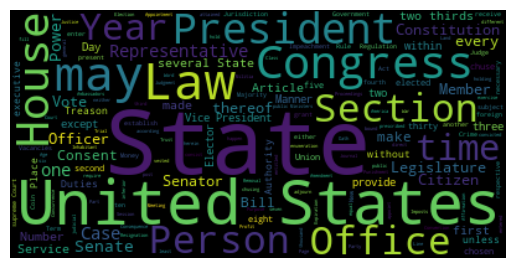

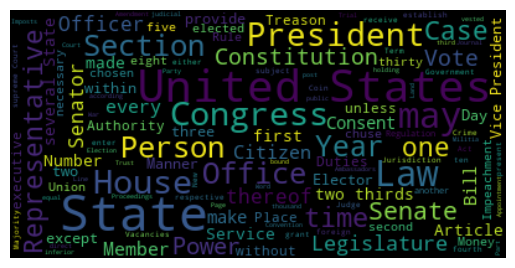

In [4]:
# !/usr/bin/env python
"""
Minimal Example
===============
Generating a square wordcloud from the US constitution using default arguments.
# https://github.com/amueller/word_cloud/tree/master/examples
"""
import os
import pandas as pd
from os import path
from wordcloud import WordCloud

# get data directory (using getcwd() is needed to support running example in generated IPython notebook)
# d = path.dirname(__file__) if "__file__" in locals() else os.getcwd()

d =r'C:\Users\yuhang.zhang\Documents\GitHub\word_cloud\examples'
    
# Read the whole text.
text = open(path.join(d, 'constitution.txt')).read()

# Generate a word cloud image
wordcloud = WordCloud().generate(text)

# Display the generated image:
# the matplotlib way:
import matplotlib.pyplot as plt
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

# lower max_font_size
wordcloud = WordCloud(max_font_size=40).generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# The pil way (if you don't have matplotlib)
# image = wordcloud.to_image()
# image.show()

In [58]:
sub_keyword_list1 = ['5th generation','4th generation','fifth generation','fourth generation',
                     'bi-directional','low temperature','ultra-low temperature']
sub_keyword_list2 = ['district heating','district cooling','district energy','district heat pump']

sub_keyword_list = sub_keyword_list1 + sub_keyword_list2 

new_list = []
for item in sub_keyword_list:
    # Split the item by space and append the resulting list to the new list
    new_list.extend(item.split())
    
new_list = list(set(new_list))
new_list

['ultra-low',
 'pump',
 '4th',
 'fourth',
 'generation',
 'heating',
 'cooling',
 'energy',
 '5th',
 'fifth',
 'temperature',
 'district',
 'low',
 'heat',
 'bi-directional']

In [62]:
comment_words

'fifth-generation district heating and cooling systems: a review of recent advancements and implementation barriers district heating and cooling networks with decentralised energy substations: opportunities and barriers for holistic energy system decarbonisation design optimization of a district heating and cooling system with a borehole seasonal thermal energy storage the efficiency of innovative technologies for transition to 4th generation of district heating systems in ukraine npro: a web-based planning tool for designing district energy systems and thermal networks 5th generation district heating and cooling network planning: a dantzig–wolfe decomposition approach data-driven prediction of energy consumption of district cooling systems (dcs) based on the weather forecast data research progress on the fifth-generation district heating system based on heat pump technology … source heat pump driven by reciprocating engine firing biomethane from wastewater treatment plant sludge in a 

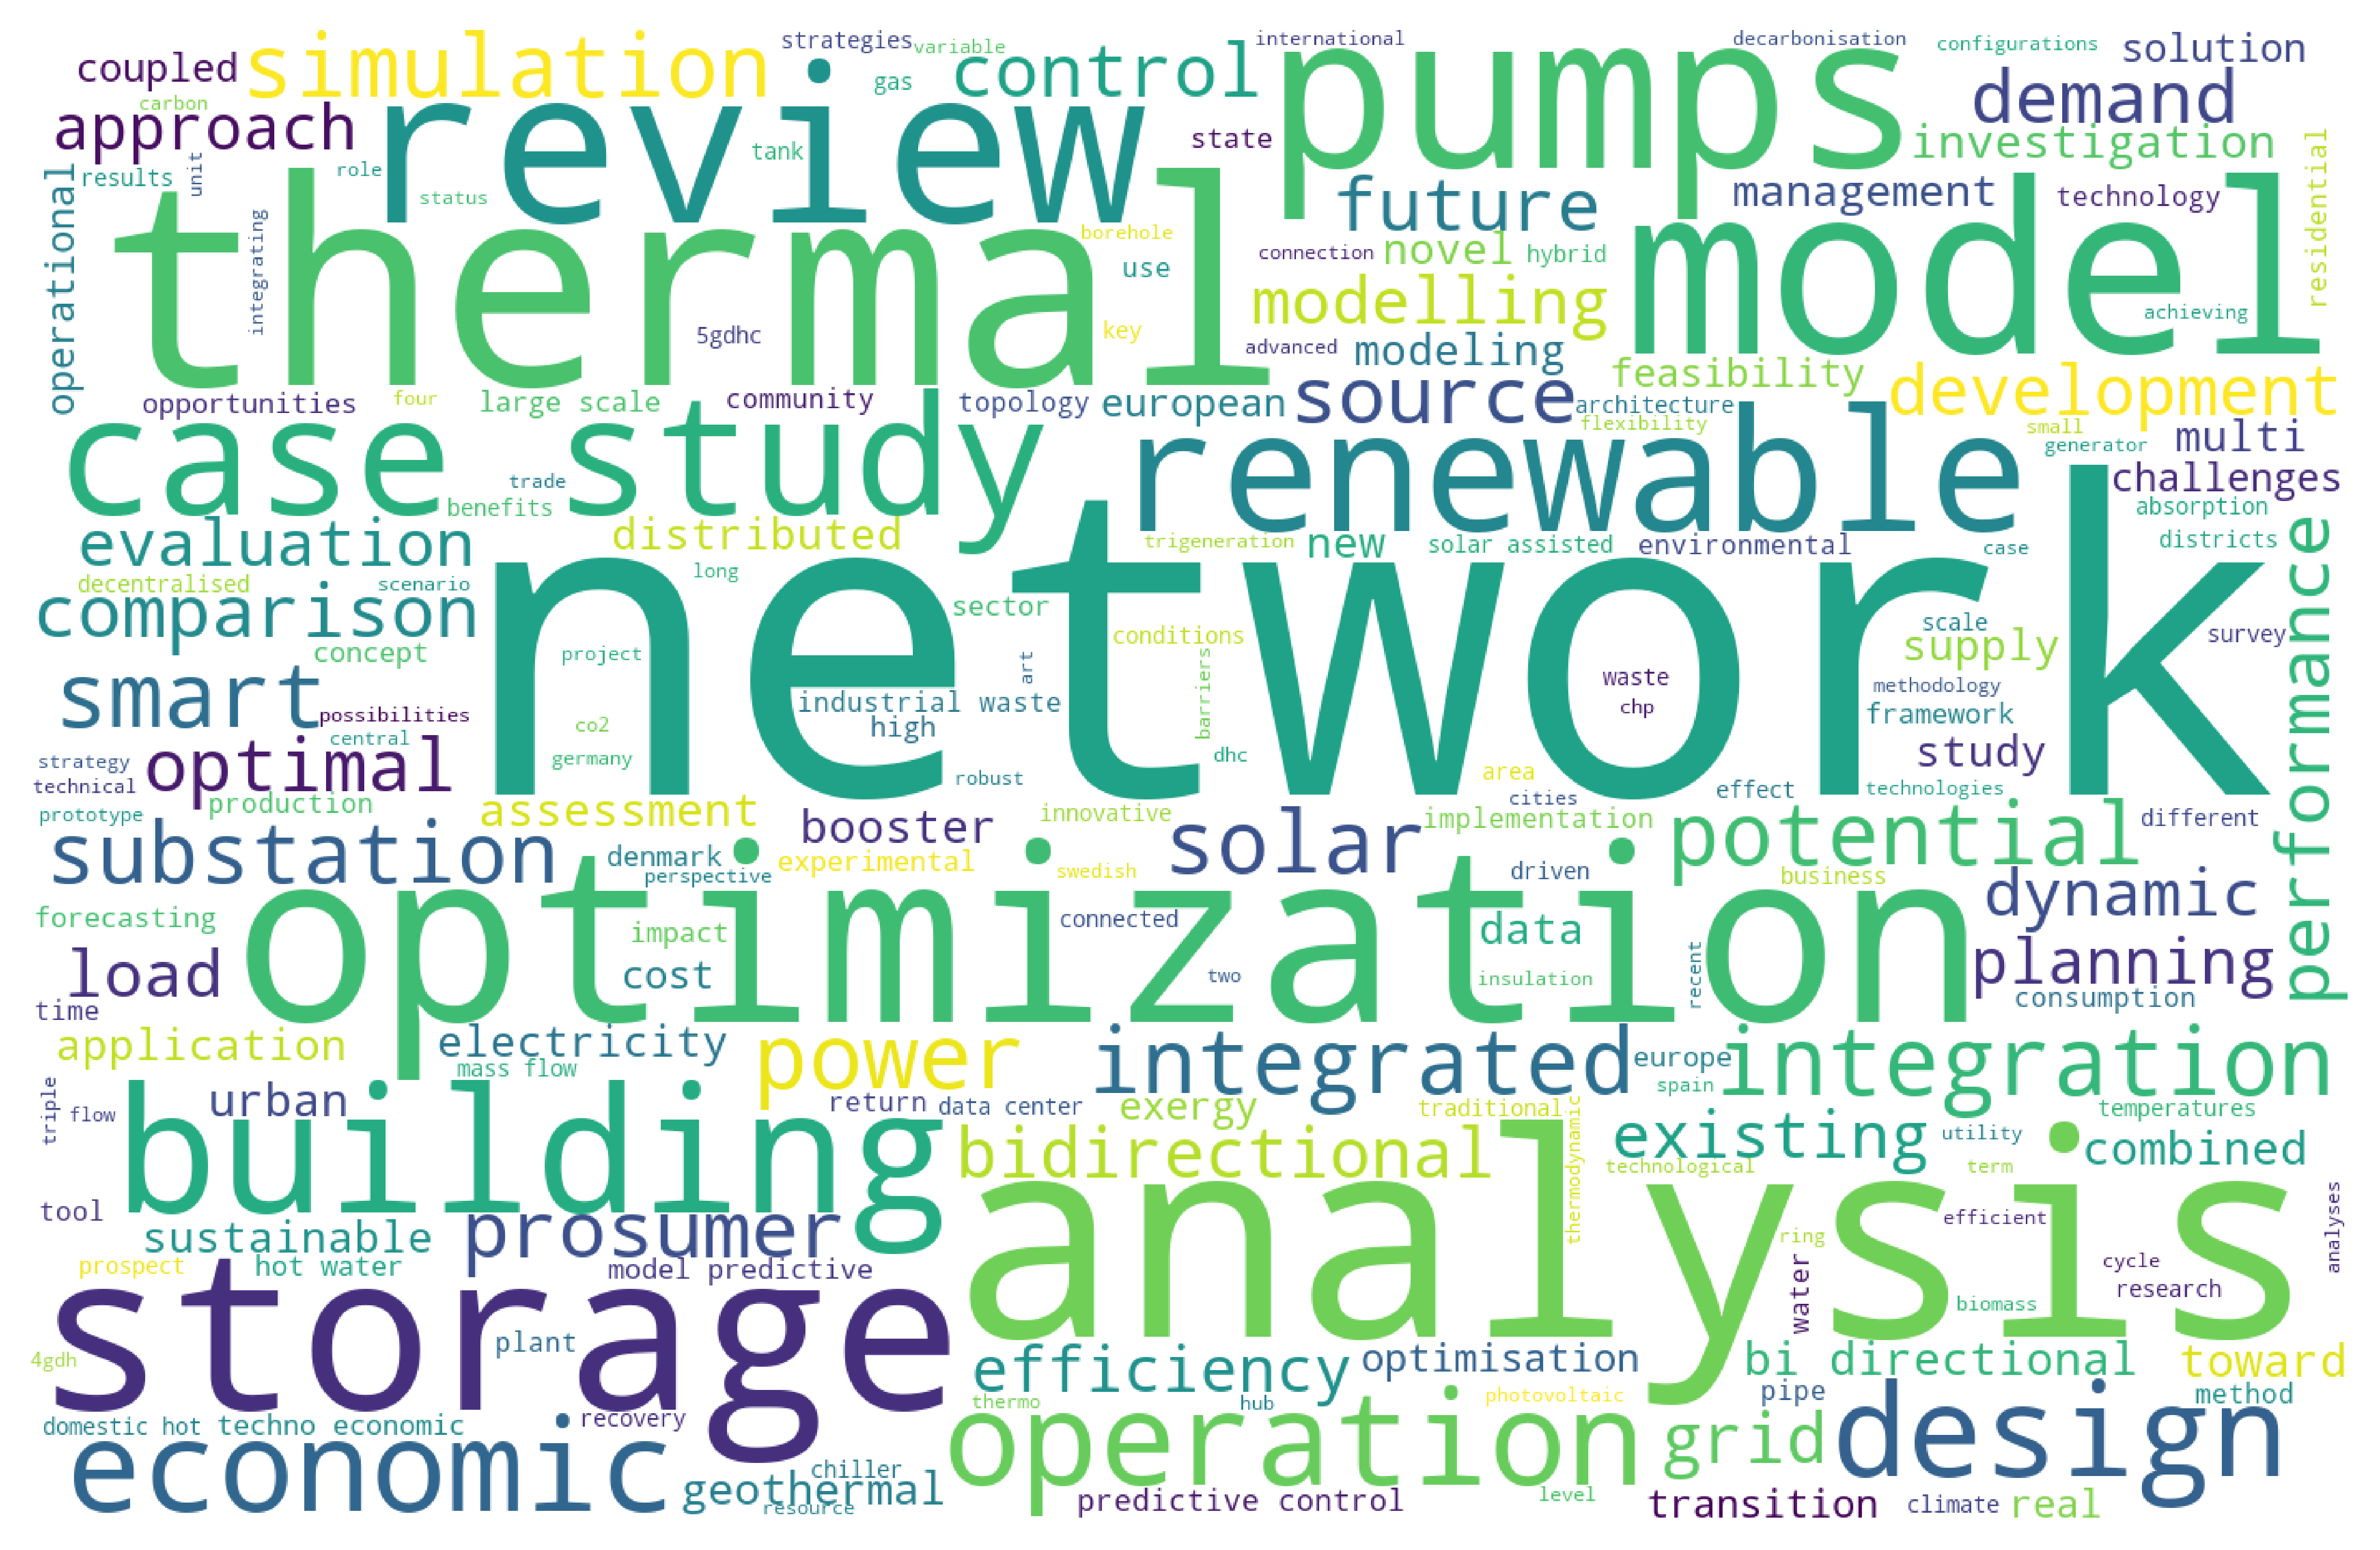

In [110]:
import os
import numpy as np
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
np.random.seed(0)

file_loc = r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\30 - Papers\2401_ULTDHCReview\Literature"

df = pd.read_csv(os.path.join(file_loc,"filtered_0719.csv"),
                          index_col = 0
                         )

personal_list = ['â','system','systems','ultra','based','using']
stopwords = list(STOPWORDS)+ new_list+personal_list # Common english words

comment_words = ''
for i in range(len(df)):
    val = df.iat[i, 0] # 0
    # typecaste each val to string
    val = str(val)
    # split the value
    tokens = val.split()
    # Converts each token into lowercase
    for j in range(len(tokens)):
        tokens[j] = tokens[j].lower()

    comment_words += " ".join(tokens)+" "
    
# font_path=r'C:\Users\yuhang.zhang\OneDrive - Texas A&M University\Jupyter\DroidSansMono.ttf'

wordcloud = WordCloud(
    width=1400, height=900,
                      background_color='white',
                      stopwords=stopwords,
                      min_font_size=8
                     ).generate(comment_words)

# plot the WordCloud image
plt.figure(figsize=(8, 8), facecolor=None,dpi= 600)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig(os.path.join(pic_loc,'word_cloud.svg'), format='svg')
plt.show()

In [65]:
df

,title,num_citations,year,excerpt,url,url_pdf,indicator,key_words
0,Fifth-generation district heating and cooling ...,13,2023,… Bidirectional energy flows have important im...,https://www.sciencedirect.com/science/article/...,NaN,0,"bidirectional, district energy"
1,District heating and cooling networks with dec...,6,2023,… heat decarbonisation arsenal is unclear as e...,https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
2,Design optimization of a district heating and ...,5,2023,… energy storages are implemented in newer gen...,https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
3,The efficiency of innovative technologies for ...,3,2023,… and 5th generations … heat recovery from the...,https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
4,nPro: A web-based planning tool for designing ...,3,2023,… These decentralized and bidirectional local ...,https://www.sciencedirect.com/science/article/...,NaN,0,"bidirectional, district energy"
...,...,...,...,...,...,...,...,...
440,Operational optimisation of a complex trigener...,95,2013,"… , heating and cooling. This polygeneration s...",https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
442,Static study of traditional and ring networks ...,68,2013,… District heating is a widely used form of he...,https://www.sciencedirect.com/science/article/...,NaN,0,"5th generation, district heating and cooling"
444,Economic viability of incorporating multi-effe...,18,2013,… district cooling. The results indicate that ...,https://www.sciencedirect.com/science/article/...,NaN,0,"low temperature, district cooling"
445,Towards an architecture for integrated Gas Dis...,14,2013,"… Thus, this paper focuses on exploring more e...",https://ieeexplore.ieee.org/abstract/document/...,NaN,0,"5th generation, district cooling"


In [114]:
import os
import numpy as np
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
np.random.seed(0)

file_loc = r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\30 - Papers\2401_ULTDHCReview\Literature"
pic_loc = r"C:\Users\yuhang.zhang\OneDrive - Texas A&M University\30 - Papers\2401_ULTDHCReview\Pictures"

df = pd.read_csv(
                 os.path.join(file_loc,"240719_330.csv"),
                #  os.path.join(file_loc,"240719_62.csv"),
                          index_col = 0
                         )

personal_list = ['â','system','systems','ultra','based','using']

stopwords = list(STOPWORDS) + new_list + personal_list # Common english words

comment_words = ''
for i in range(len(df)):
    val = df.iat[i, 0] # 0
    # typecaste each val to string
    val = str(val)
    # split the value
    tokens = val.split()
    # Converts each token into lowercase
    for j in range(len(tokens)):
        tokens[j] = tokens[j].lower()

    comment_words += " ".join(tokens)+" "
    
# font_path=r'C:\Users\yuhang.zhang\OneDrive - Texas A&M University\Jupyter\DroidSansMono.ttf'

wordcloud = WordCloud(width=1400, height=900,
                      background_color='white',
                      stopwords=stopwords,
                      min_font_size=8,
                    #   max_words = 200,   # Maximum number of words
                      random_state = 2,
                     ).generate(comment_words)

# plot the WordCloud image
# plt.figure(figsize=(8, 8), facecolor=None,dpi= 600)
plt.figure(figsize=(14, 9), facecolor=None,dpi= 1200)
plt.imshow(wordcloud)

plt.axis("off")
plt.tight_layout(pad=0)
# Save the figure as an SVG file
plt.savefig(os.path.join(pic_loc,'word_cloud.svg'), format='svg')

plt.show()

wordcloud.words_

{'network': 1.0,
 'analysis': 0.29357798165137616,
 'thermal': 0.28440366972477066,
 'optimization': 0.22935779816513763,
 'storage': 0.21100917431192662,
 'review': 0.2018348623853211,
 'pumps': 0.2018348623853211,
 'model': 0.1834862385321101,
 'building': 0.1743119266055046,
 'renewable': 0.1651376146788991,
 'integration': 0.1651376146788991,
 'power': 0.1559633027522936,
 'design': 0.1559633027522936,
 'economic': 0.14678899082568808,
 'solar': 0.13761467889908258,
 'integrated': 0.13761467889908258,
 'operation': 0.13761467889908258,
 'potential': 0.13761467889908258,
 'case study': 0.13761467889908258,
 'simulation': 0.12844036697247707,
 'control': 0.11926605504587157,
 'smart': 0.11926605504587157,
 'development': 0.11926605504587157,
 'performance': 0.11926605504587157,
 'substation': 0.11926605504587157,
 'optimal': 0.11009174311926606,
 'future': 0.11009174311926606,
 'existing': 0.10091743119266056,
 'comparison': 0.10091743119266056,
 'modelling': 0.10091743119266056,
 'd

In [85]:
# Print the words and their frequencies
word_frequencies = wordcloud.words_
for word, freq in word_frequencies.items():
    print(f"{word}: {freq:.4f}")
wordcloud.words_

network: 1.0000
analysis: 0.2936
thermal: 0.2844
optimization: 0.2294
storage: 0.2110
review: 0.2018
pumps: 0.2018
model: 0.1835
building: 0.1743
renewable: 0.1651
integration: 0.1651
power: 0.1560
design: 0.1560
economic: 0.1468
solar: 0.1376
integrated: 0.1376
operation: 0.1376
potential: 0.1376
case study: 0.1376
simulation: 0.1284
control: 0.1193
smart: 0.1193
development: 0.1193
performance: 0.1193
substation: 0.1193
optimal: 0.1101
future: 0.1101
existing: 0.1009
comparison: 0.1009
modelling: 0.1009
demand: 0.1009
evaluation: 0.1009
dynamic: 0.1009
source: 0.1009
load: 0.0917
efficiency: 0.0917
combined: 0.0917
booster: 0.0917
bidirectional: 0.0917
prosumer: 0.0917
toward: 0.0917
urban: 0.0826
investigation: 0.0826
approach: 0.0826
grid: 0.0826
assessment: 0.0826
bi directional: 0.0826
distributed: 0.0734
management: 0.0734
planning: 0.0734
electricity: 0.0734
modeling: 0.0734
supply: 0.0734
novel: 0.0734
new: 0.0734
application: 0.0734
study: 0.0642
operational: 0.0642
optimisat

{'network': 1.0,
 'analysis': 0.29357798165137616,
 'thermal': 0.28440366972477066,
 'optimization': 0.22935779816513763,
 'storage': 0.21100917431192662,
 'review': 0.2018348623853211,
 'pumps': 0.2018348623853211,
 'model': 0.1834862385321101,
 'building': 0.1743119266055046,
 'renewable': 0.1651376146788991,
 'integration': 0.1651376146788991,
 'power': 0.1559633027522936,
 'design': 0.1559633027522936,
 'economic': 0.14678899082568808,
 'solar': 0.13761467889908258,
 'integrated': 0.13761467889908258,
 'operation': 0.13761467889908258,
 'potential': 0.13761467889908258,
 'case study': 0.13761467889908258,
 'simulation': 0.12844036697247707,
 'control': 0.11926605504587157,
 'smart': 0.11926605504587157,
 'development': 0.11926605504587157,
 'performance': 0.11926605504587157,
 'substation': 0.11926605504587157,
 'optimal': 0.11009174311926606,
 'future': 0.11009174311926606,
 'existing': 0.10091743119266056,
 'comparison': 0.10091743119266056,
 'modelling': 0.10091743119266056,
 'd

{'network': 1.0,
 'analysis': 0.29357798165137616,
 'thermal': 0.28440366972477066,
 'optimization': 0.22935779816513763,
 'storage': 0.21100917431192662,
 'review': 0.2018348623853211,
 'pumps': 0.2018348623853211,
 'model': 0.1834862385321101,
 'building': 0.1743119266055046,
 'renewable': 0.1651376146788991,
 'integration': 0.1651376146788991,
 'power': 0.1559633027522936,
 'design': 0.1559633027522936,
 'economic': 0.14678899082568808,
 'solar': 0.13761467889908258,
 'integrated': 0.13761467889908258,
 'operation': 0.13761467889908258,
 'potential': 0.13761467889908258,
 'case study': 0.13761467889908258,
 'simulation': 0.12844036697247707,
 'control': 0.11926605504587157,
 'smart': 0.11926605504587157,
 'development': 0.11926605504587157,
 'performance': 0.11926605504587157,
 'substation': 0.11926605504587157,
 'optimal': 0.11009174311926606,
 'future': 0.11009174311926606,
 'existing': 0.10091743119266056,
 'comparison': 0.10091743119266056,
 'modelling': 0.10091743119266056,
 'd

In [20]:
%pip show wordcloud

Name: wordcloud
Version: 1.9.2
Summary: A little word cloud generator
Home-page: https://github.com/amueller/word_cloud
Author: Andreas Mueller
Author-email: t3kcit+wordcloud@gmail.com
License: MIT
Location: c:\programdata\anaconda3\lib\site-packages\wordcloud-1.9.2-py3.9-win-amd64.egg
Requires: numpy, pillow, matplotlib
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [16]:
comment_words

"heat pump efficiency in fifth generation ultra-low temperature district heating networks using a wastewater heat source ultra-low temperature district heating system with central heat pump and local boosters for low-heat-density area: analyses on a real case in denmark evaluating the cost of heat for end users in ultra low temperature district heating networks with booster heat pumps performance of ultra low temperature district heating systems with utility plant and booster heat pumps steady state behavior of a booster heat pump for hot water supply in ultra-low temperature district heating network energetic and economic analysis of decoupled strategy for heating and cooling production with co2 booster heat pumps for ultra-low temperature districtâ â\x80¦ model predictive control for a heat booster substation in ultra low temperature district heating systems economic comparison of low-temperature and ultra-low-temperature district heating for new building developments with low heat d

In [20]:
import pandas as pd
df = pd.read_csv(r"D:\Github\word-cloud\results\topics\machine learning control\summary.csv"
                 , encoding="latin-1")  # summary_cloud06022022
df

,title,num_citations,year,excerpt,url,url_pdf,indicator,key_words
0,A SCADA system for energy management in intell...,126,2012,â¦ into the future allowing the multi-users t...,https://www.sciencedirect.com/science/article/...,NaN,0,"intelligent, MPC, in buildings"
1,Model predictive controller for active demand ...,65,2012,â¦ III. MPC FOR ADSM IN AN INTELLIGENT BUILDI...,https://ieeexplore.ieee.org/abstract/document/...,NaN,0,"intelligent, MPC, in buildings"
2,Control-oriented thermal modeling of multizone...,51,2016,"â¦ methods [for exam- ple, model predictive c...",https://ieeexplore.ieee.org/abstract/document/...,NaN,0,"intelligent, MPC, in buildings"
3,Active load management in an intelligent build...,27,2011,"â¦ open-loop performance objective, subject t...",https://ieeexplore.ieee.org/abstract/document/...,NaN,0,"intelligent, MPC, in buildings"
4,Intelligent systems for building energy and oc...,12,2018,"â¦ The keywords 'building energy management',...",https://www.mdpi.com/1996-1073/11/10/2604,NaN,0,"intelligent, MPC, in buildings"
...,...,...,...,...,...,...,...,...
102,Reinforcement learning for optimal control of ...,165,2015,â¦ A model predictive control approach is unn...,https://www.sciencedirect.com/science/article/...,NaN,0,"reinforcement learning, control, in buildings"
103,Energy optimization associated with thermal co...,112,2019,â¦ reinforcement learning with the new deep l...,https://www.sciencedirect.com/science/article/...,NaN,0,"reinforcement learning, control, in buildings"
104,Anomaly detection based on machine learning in...,60,2020,"â¦ indoor climate control. In this study, we ...",https://www.sciencedirect.com/science/article/...,NaN,0,"reinforcement learning, daylight control, HVAC"
105,Octopus: Deep reinforcement learning for holis...,81,2019,â¦ have been proposed based on reinforcement ...,https://dl.acm.org/doi/abs/10.1145/3360322.336...,NaN,0,"reinforcement learning, daylight control, HVAC"
